In [64]:
import tensorflow as tf
from tensorflow import keras
import sklearn
import matplotlib.pyplot as plt
import pandas as pd 
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import keras
from plot_keras_history import show_history, plot_history
import numpy as np
from keras import layers

In [65]:
def generate_regression_data():
    X, y = make_regression(n_samples=1000, n_features=5, n_informative=3, noise=15)
    
    y = y + 30 * np.sin(X[:, 0])
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(X_train)
    x_test_scaled = scaler.transform(X_test)

    return x_train_scaled, x_test_scaled, y_train, y_test

In [66]:
def build_model(input_dim, hidden_layers: list, activation):

    model = Sequential()

    model.add(layers.Input(shape=(input_dim, )))
    
    for i in hidden_layers:
        model.add(layers.Dense(i, activation=activation))

    model.add(layers.Dense(1))

    return model 

In [81]:
def train_model(model, X_train, y_train, epochs):
    
    model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss='mse')

    history = model.fit(X_train, y_train, validation_split = 0.2, epochs= epochs)

    return history

In [105]:
def plot_history(history, title):

    plt.plot(history.history['loss'], label='Trening (loss)', color='blue')
    plt.plot(history.history['val_loss'], label='Walidacja (val_loss)', color='red')
    plt.title(title)
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.yscale('log')
    plt.legend()
    plt.show()

In [101]:
X_train_scaled, X_test_scaled, y_train, y_test = generate_regression_data()

In [102]:
model = build_model(5, [16], 'relu')

In [97]:
history = train_model(model, X_train_scaled, y_train, epochs=200)

Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 15164.2061 - val_loss: 18265.5723
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 14805.5186 - val_loss: 17655.1055
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 14066.0996 - val_loss: 16389.8086
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12753.9463 - val_loss: 14405.8545
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10872.9668 - val_loss: 11794.6094
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8551.5225 - val_loss: 8892.2520
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6178.9941 - val_loss: 6139.6089
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4090.9094 - val_loss: 3940.3257
Epoch 9/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2548.6138 - val_loss: 2387.5837
Epoch 10/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1565.3253 - val_loss: 1479.7239
Epoch 11/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1033.8118 - val_los

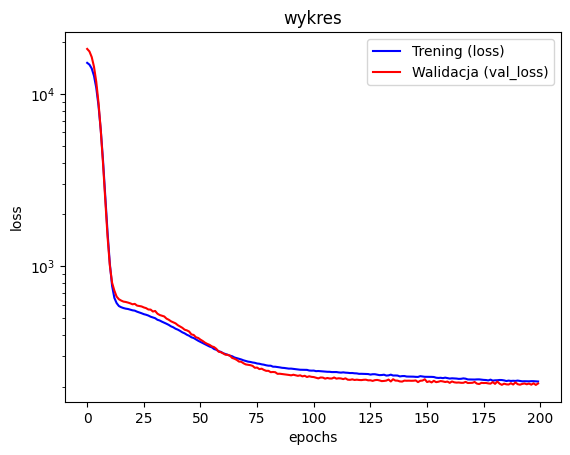

In [106]:
wykres = plot_history(history, "wykres")

In [104]:
# jak linie sie rozjezdaja to oznacza overfitting

# zadanie 2

In [182]:
dict1 = {"no_hidden": [], "small": [8], "medium": [32], "two_layers": [64, 64], "large": [128, 128, 128]}

def compare_models(configs, data, epochs):

    histories = {}

    X_train_scaled, y_train = data

    for name, layers_num in configs.items():

        model= Sequential()
        model.add(layers.Input(shape=(5, )))
        
        for layer in layers_num:
    
            model.add(layers.Dense(layer, activation='relu'))

        model.add(layers.Dense(1))
        model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),loss='mse',metrics=['mae'])
        history = model.fit(X_train, y_train, validation_split = 0.2, verbose=0, epochs= epochs)
        histories[name] = history
        
    return histories

In [197]:
data_xy = (X_train_scaled, y_train)

In [198]:
models = compare_models(dict1, data_xy, epochs=150)

In [199]:
models

{'no_hidden': <keras.src.callbacks.history.History at 0x12f519550>,
 'small': <keras.src.callbacks.history.History at 0x12f582040>,
 'medium': <keras.src.callbacks.history.History at 0x12f75b3f0>,
 'two_layers': <keras.src.callbacks.history.History at 0x12f8f5390>,
 'large': <keras.src.callbacks.history.History at 0x12f8f57f0>}

In [200]:
models['no_hidden'].history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

In [201]:
data = []
for name, history in models.items():
    mini_data = {"name" :name,
                 "mae" : history.history['mae'][-1],
                 "loss": history.history['loss'][-1],
                 "val_loss": history.history['val_loss'][-1]
                }
    data.append(mini_data)

df = pd.DataFrame(data)
df

,name,mae,loss,val_loss
0,no_hidden,95.687950,14210.206055,18003.472656
1,small,95.515518,14171.146484,18054.082031
2,medium,94.962982,13970.814453,18235.535156
3,two_layers,90.979713,12848.391602,19467.353516
4,large,48.752659,4093.722656,29676.662109


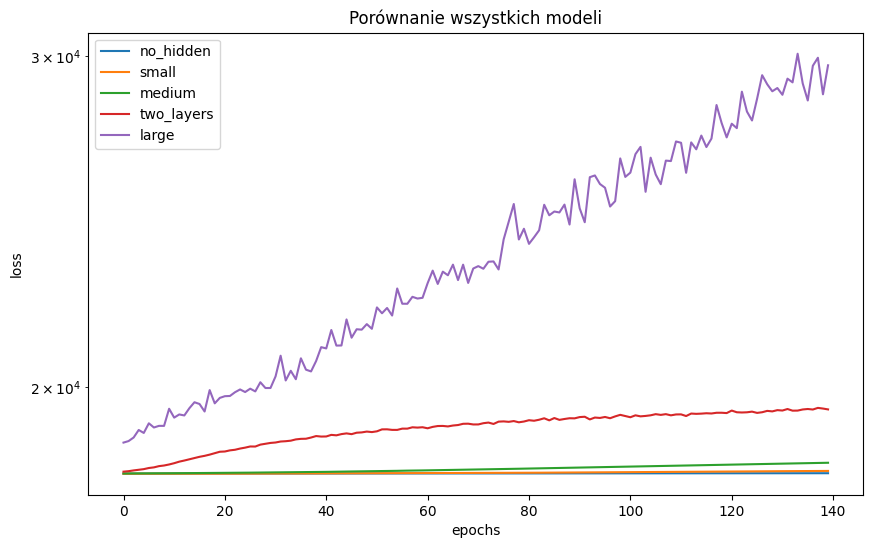

In [202]:
def plot_histories(histories):
    plt.figure(figsize=(10, 6))  

    for name, history in histories.items():  
        plt.plot(history.history['val_loss'][10:], label=name)

    plt.yscale('log')
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.title("Porównanie wszystkich modeli")
    plt.legend()
    plt.show() 

plot_histories(models)

In [203]:
# najlepiej wyszedl model bez warstw, a najgorzej model large. przeuczenia nie ma tylko na large j